# Online Retail Dataset

### Importing libraries 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import os
print(os.getcwd())

C:\Users\Vivek


## Data Overview

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Vivek\OneDrive - Vishvaraj Environment Pvt Ltd\Desktop\VSCode\Python Projects\21DAYSCHALLENGE\Day-03-Online-Retail-Analysis\dataset\data.csv",encoding="latin1")

df.shape


(541909, 8)

#### What are the column names?

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

#### What are the data types?

In [7]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

#### Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### First 5 rows

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### Last 5 rows

In [10]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


#### Summary Statistics

In [11]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


#### Summary of categorical columns?

In [12]:
df.describe(include=object)

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


#### How many unique values?

In [13]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

#### Time period covered?

In [14]:
df["InvoiceDate"].min()

'1/10/2011 10:04'

In [15]:
df["InvoiceDate"].max()

'9/9/2011 9:52'

## Data Cleaning

#### Missing Value

In [16]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

#### Missing Percentage

In [17]:
(df.isnull().sum()/len(df))*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

#### Duplicate Rows

In [18]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Length: 541909, dtype: bool

In [19]:
df.duplicated().sum()

np.int64(5268)

#### Remove Duplicates

In [39]:
df.drop_duplicates(inplace=True)

#### Check Negative Quantity
##### Are there returned products?

In [20]:
df[df["Quantity"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


#### Check Zero or Negative Price
#### Are there invalid prices?

In [21]:
df[df["UnitPrice"]<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,12/8/2011 13:58,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,12/8/2011 13:58,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom


#### Convert Date
#### Is InvoiceDate in datetime format?

In [22]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

#### Check Cancelled Orders
#### Which orders are cancelled?

In [23]:
df[df["InvoiceNo"].str.startswith("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


#### CustomerID Cleaning
#### Should missing Customer IDs be removed?

In [24]:
df=df.dropna(subset=["CustomerID"])

In [25]:
df.head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


## Data Cleaning 

#### Are there any missing values?

In [26]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

#### What percentage of the data is missing?

In [27]:
(df.isnull().sum()/len(df))*100

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
dtype: float64

#### Does the dataset contain duplicate rows?

In [28]:
df.duplicated().sum()

np.int64(5225)

In [29]:
duplicates = df[df.duplicated()]
duplicates

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [30]:
df[df.duplicated(keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [31]:
df[df.duplicated(subset=["InvoiceNo"], keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [32]:
duplicate_invoices = df["InvoiceNo"].value_counts()

len(duplicate_invoices[duplicate_invoices > 1])

18795

In [33]:
df[df.duplicated(subset=["StockCode"], keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [34]:
duplicate_invoices = df["StockCode"].value_counts()

len(duplicate_invoices[duplicate_invoices > 1])

3523

#### Remove Duplicates

In [35]:
df.drop_duplicates(inplace=True)

In [36]:

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows After: 0


In [37]:
print("Shape After:", df.shape)

Shape After: (401604, 8)


#### Are there returned products?

In [38]:
df[df["Quantity"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


#### Are there invalid prices?

In [39]:
df[df["UnitPrice"]<=0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


#### Is InvoiceDate in datetime format?

In [40]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"]

0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
541904   2011-12-09 12:50:00
541905   2011-12-09 12:50:00
541906   2011-12-09 12:50:00
541907   2011-12-09 12:50:00
541908   2011-12-09 12:50:00
Name: InvoiceDate, Length: 401604, dtype: datetime64[ns]

#### Which orders are cancelled?

In [41]:
df[df["InvoiceNo"].str.startswith("C")]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


#### Should missing Customer IDs be removed?

In [42]:
df=df.dropna(subset=["CustomerID"])

## Feature Engineering

#### Total Revenue per Transaction
#### How much money was generated in each transaction?

In [43]:
df["TotalPrice"]=df["Quantity"]*df["UnitPrice"]
df["TotalPrice"]

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: TotalPrice, Length: 401604, dtype: float64

#### Year

#### Which year does the transaction belong to?

In [44]:
df["Year"]=df["InvoiceDate"].dt.year
df["Year"]

0         2010
1         2010
2         2010
3         2010
4         2010
          ... 
541904    2011
541905    2011
541906    2011
541907    2011
541908    2011
Name: Year, Length: 401604, dtype: int32

#### Month 
#### Which Month had the sale ?

In [46]:
df["Month"]=df["InvoiceDate"].dt.month
df["Month"]

0         12
1         12
2         12
3         12
4         12
          ..
541904    12
541905    12
541906    12
541907    12
541908    12
Name: Month, Length: 401604, dtype: int32

#### Month Name

In [48]:
df["MonthName"]=df["InvoiceDate"].dt.month_name()
df["MonthName"]

0         December
1         December
2         December
3         December
4         December
            ...   
541904    December
541905    December
541906    December
541907    December
541908    December
Name: MonthName, Length: 401604, dtype: object

#### Day 

In [49]:
df["Day"]=df["InvoiceDate"].dt.day
df["Day"]

0         1
1         1
2         1
3         1
4         1
         ..
541904    9
541905    9
541906    9
541907    9
541908    9
Name: Day, Length: 401604, dtype: int32

#### Weekday

In [50]:
df["Weekday"]=df["InvoiceDate"].dt.day_name()
df["Weekday"]

0         Wednesday
1         Wednesday
2         Wednesday
3         Wednesday
4         Wednesday
            ...    
541904       Friday
541905       Friday
541906       Friday
541907       Friday
541908       Friday
Name: Weekday, Length: 401604, dtype: object

#### Hour

In [51]:
df["Hour"]=df["InvoiceDate"].dt.hour
df["Hour"]

0          8
1          8
2          8
3          8
4          8
          ..
541904    12
541905    12
541906    12
541907    12
541908    12
Name: Hour, Length: 401604, dtype: int32

#### Cancelled Order Flag  
#### Is this transaction cancelled?

In [52]:
df["IsCancelled"]=df["InvoiceNo"].str.startswith("C")
df["IsCancelled"]

0         False
1         False
2         False
3         False
4         False
          ...  
541904    False
541905    False
541906    False
541907    False
541908    False
Name: IsCancelled, Length: 401604, dtype: bool

### Exploratory Data Analysis (EDA)
##### Sales Analysis

#### What is the total Revenue?

In [53]:
df["TotalPrice"].sum()

np.float64(8278519.424)

#### What is the average transaction value?

In [54]:
df["TotalPrice"].mean()

np.float64(20.613637872132745)

#### Maximum Sale

In [55]:
df["TotalPrice"].max()

168469.6

#### Minimum Sale

In [56]:
df["TotalPrice"].min()

-168469.6

#### How many countries?


In [57]:
df["Country"].nunique()

37

#### Which countries are present?

In [58]:
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

#### Top Countries by Revenue

In [59]:
df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

Country
United Kingdom          6747156.154
Netherlands              284661.540
EIRE                     250001.780
Germany                  221509.470
France                   196626.050
Australia                137009.770
Switzerland               55739.400
Spain                     54756.030
Belgium                   40910.960
Sweden                    36585.410
Japan                     35340.620
Norway                    35163.460
Portugal                  28995.760
Finland                   22326.740
Channel Islands           20076.390
Denmark                   18768.140
Italy                     16890.510
Cyprus                    12858.760
Austria                   10154.320
Singapore                  9120.390
Poland                     7213.140
Israel                     6988.400
Greece                     4710.520
Iceland                    4310.000
Canada                     3666.380
Unspecified                2660.770
Malta                      2505.470
United Arab Emirates

#### Top Countries by Orders

In [60]:
df["Country"].value_counts()

Country
United Kingdom          356728
Germany                   9480
France                    8475
EIRE                      7475
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1877
Portugal                  1471
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
USA                        291
Israel                     247
Unspecified                241
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon                     45


### Product Analysis
#### Best Selling Products

In [62]:
df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS      53119
JUMBO BAG RED RETROSPOT                44963
ASSORTED COLOUR BIRD ORNAMENT          35215
WHITE HANGING HEART T-LIGHT HOLDER     34128
PACK OF 72 RETROSPOT CAKE CASES        33386
                                       ...  
PINK POODLE HANGING DECORATION           -12
CRUK Commission                          -16
ASSORTED TUTTI FRUTTI ROUND BOX          -24
Discount                               -1194
ROTATING SILVER ANGELS T-LIGHT HLDR    -1475
Name: Quantity, Length: 3896, dtype: int64

#### Highest Revenue Products

In [63]:
df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False)

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
                                        ...    
WHITE CHERRY LIGHTS                      -54.00
CHALKBOARD KITCHEN ORGANISER             -87.80
Discount                               -5696.22
CRUK Commission                        -7933.43
Manual                                -58745.46
Name: TotalPrice, Length: 3896, dtype: float64

#### Most Expensive Products

In [64]:
df.groupby("Description")["UnitPrice"].max().sort_values(ascending=False)

Description
Manual                                38970.000
POSTAGE                                8142.750
Discount                               1867.860
DOTCOM POSTAGE                         1599.260
CRUK Commission                        1100.440
                                        ...    
POP ART PUSH DOWN RUBBER                  0.120
FOLDING CAMPING SCISSOR W/KNIF & S        0.120
WRAP BAD HAIR DAY                         0.100
PORCELAIN BUDAH INCENSE HOLDER            0.100
PADS TO MATCH ALL CUSHIONS                0.001
Name: UnitPrice, Length: 3896, dtype: float64

#### Most Returned Products

In [65]:
df[df["Quantity"]<0]["Description"].value_counts()

Description
REGENCY CAKESTAND 3 TIER               180
Manual                                 175
POSTAGE                                 97
JAM MAKING SET WITH JARS                86
Discount                                77
                                      ... 
FOLDING UMBRELLA CREAM POLKADOT          1
JUMBO BAG CHARLIE AND LOLA TOYS          1
LARGE CAKE TOWEL PINK SPOTS              1
AIRLINE BAG VINTAGE WORLD CHAMPION       1
PAPER CRAFT , LITTLE BIRDIE              1
Name: count, Length: 1945, dtype: int64

### Customer Analysis
#### Number of Customers

In [67]:
df["CustomerID"].nunique()

4372

#### Top Customers

In [68]:
df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
             ...    
12503.0     -1126.00
17603.0     -1165.30
14213.0     -1192.20
15369.0     -1592.49
17448.0     -4287.63
Name: TotalPrice, Length: 4372, dtype: float64

#### Orders Per Customer

In [69]:
df.groupby("CustomerID")["InvoiceNo"].nunique()

CustomerID
12346.0     2
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     3
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4372, dtype: int64

#### Average Customer Spending

In [70]:
df.groupby("CustomerID")["TotalPrice"].sum().mean()

np.float64(1893.5314327538883)

### Time Analysis
#### Monthly Revenue

In [71]:
df.groupby("MonthName")["TotalPrice"].sum()

MonthName
April         425222.671
August        615078.090
December      893912.290
February      435534.070
January       473731.900
July          573112.321
June          606862.520
March         578576.210
May           647011.670
November     1126815.070
October       973306.380
September     929356.232
Name: TotalPrice, dtype: float64

#### Daily Revenue

In [72]:
df.groupby("Day")["TotalPrice"].sum()

Day
1     280486.670
2     251473.320
3     263034.110
4     310357.670
5     346360.990
6     320237.120
7     368128.590
8     285766.980
9     282350.700
10    272150.650
11    324300.420
12    214517.260
13    246931.930
14    328214.710
15    298193.331
16    272926.300
17    319935.950
18    252517.560
19    239266.540
20    351338.290
21    314684.060
22    244544.180
23    240096.360
24    253876.210
25    221804.561
26    180104.872
27    209347.630
28    289526.690
29    162888.450
30    199305.000
31    133852.320
Name: TotalPrice, dtype: float64

#### Weekday Revenue

In [73]:
df.groupby("Weekday")["TotalPrice"].sum()

Weekday
Friday       1238556.741
Monday       1271078.601
Sunday        777412.351
Thursday     1902316.050
Tuesday      1562715.681
Wednesday    1526440.000
Name: TotalPrice, dtype: float64

#### Hourly Revenue

In [74]:
df.groupby("Hour")["TotalPrice"].sum()

Hour
6        -497.350
7       31009.320
8      279985.430
9      654904.951
10    1148692.881
11    1053658.480
12    1332247.730
13    1118155.480
14     945058.221
15     896326.790
16     445930.100
17     212373.801
18     100525.120
19      44228.380
20      15920.090
Name: TotalPrice, dtype: float64

### Return Analysis
#### Number of Returns

In [75]:
(df["Quantity"]<0).sum()

np.int64(8872)

#### Return Percentage

In [76]:
((df["Quantity"]<0).sum()/len(df))*100

np.float64(2.209141343213713)

#### Returned Products

In [77]:
df[df["Quantity"]<0]["Description"].value_counts()

Description
REGENCY CAKESTAND 3 TIER               180
Manual                                 175
POSTAGE                                 97
JAM MAKING SET WITH JARS                86
Discount                                77
                                      ... 
FOLDING UMBRELLA CREAM POLKADOT          1
JUMBO BAG CHARLIE AND LOLA TOYS          1
LARGE CAKE TOWEL PINK SPOTS              1
AIRLINE BAG VINTAGE WORLD CHAMPION       1
PAPER CRAFT , LITTLE BIRDIE              1
Name: count, Length: 1945, dtype: int64

### Visualizations

In [79]:
plt.style.use("ggplot")

#### Which month generated the highest revenue?

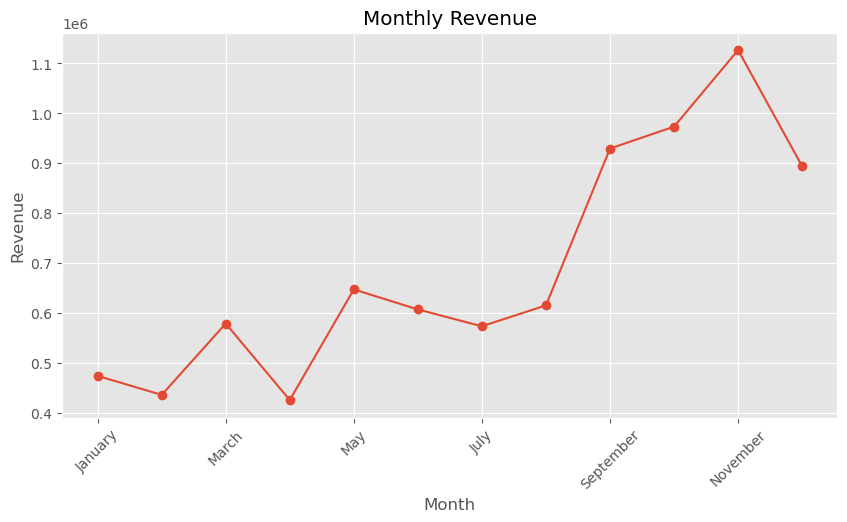

In [80]:
monthly_revenue = df.groupby("MonthName")["TotalPrice"].sum().reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

plt.figure(figsize=(10,5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

#### Which countries generated the highest revenue?

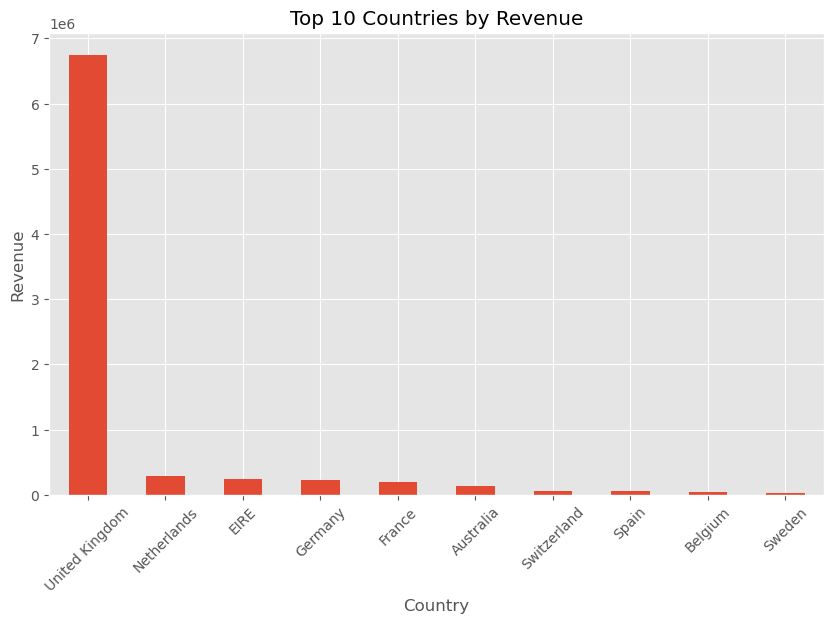

In [81]:
top_country = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_country.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

#### Which products sold the most?

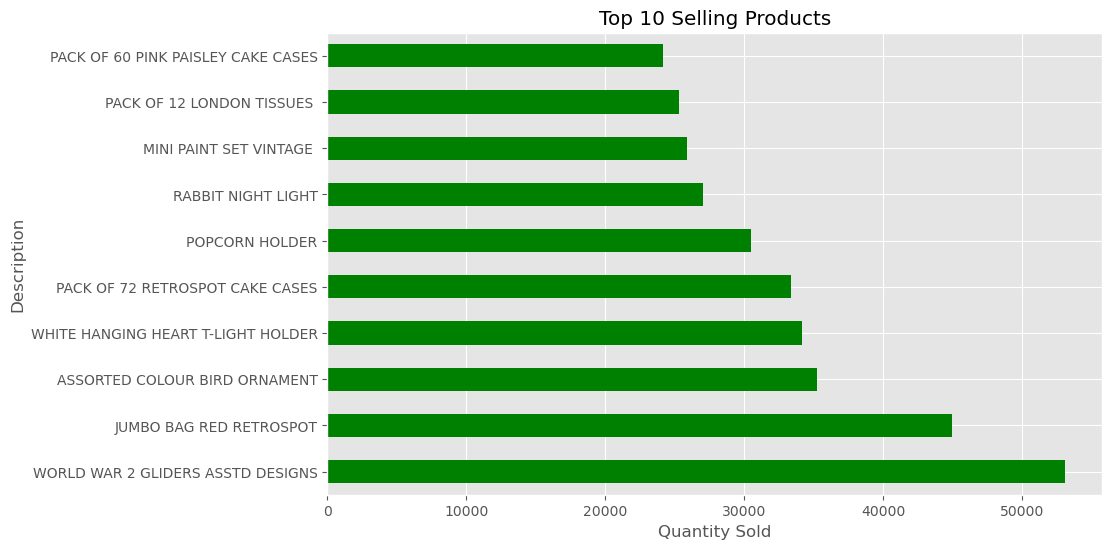

In [88]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh",color='green')
plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.show()

#### How is transaction revenue distributed?

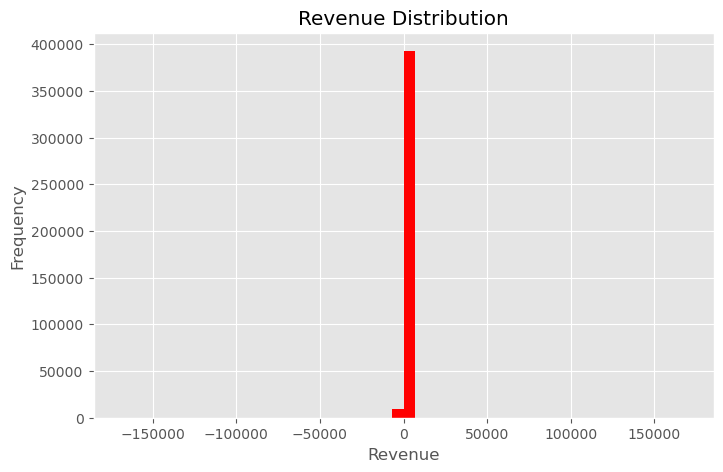

In [92]:
plt.figure(figsize=(8,5))
plt.hist(df["TotalPrice"], bins=50,color= 'red')
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

#### Unit Price Distribution

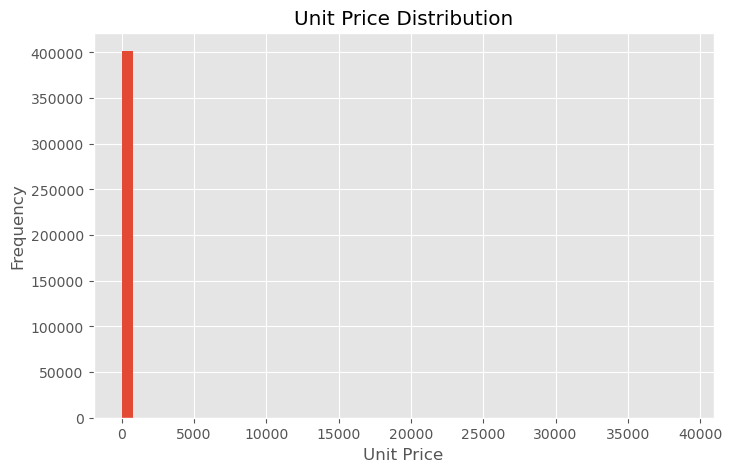

In [93]:
plt.figure(figsize=(8,5))
plt.hist(df["UnitPrice"], bins=50)
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

#### Quantity Distribution

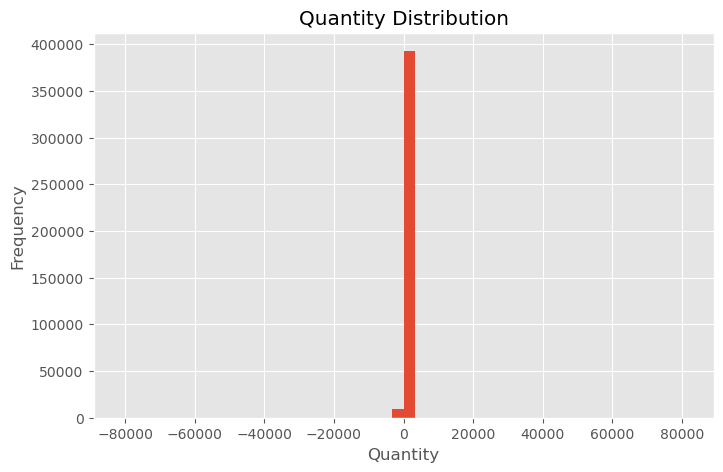

In [94]:
plt.figure(figsize=(8,5))
plt.hist(df["Quantity"], bins=50)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

#### TotalPrice Outliers

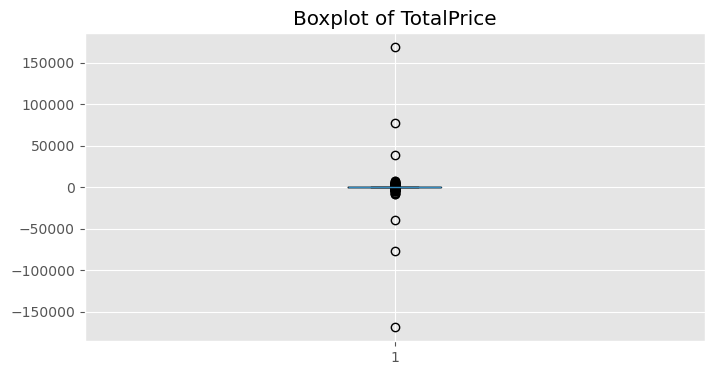

In [95]:
plt.figure(figsize=(8,4))
plt.boxplot(df["TotalPrice"])
plt.title("Boxplot of TotalPrice")
plt.show()

#### Which numerical variables are correlated?

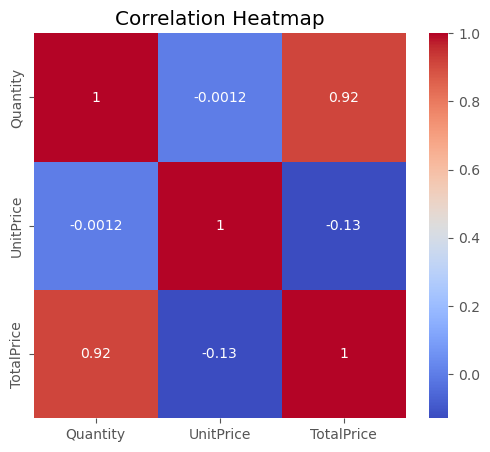

In [96]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[["Quantity","UnitPrice","TotalPrice"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

#### At what hour do customers place the most orders?

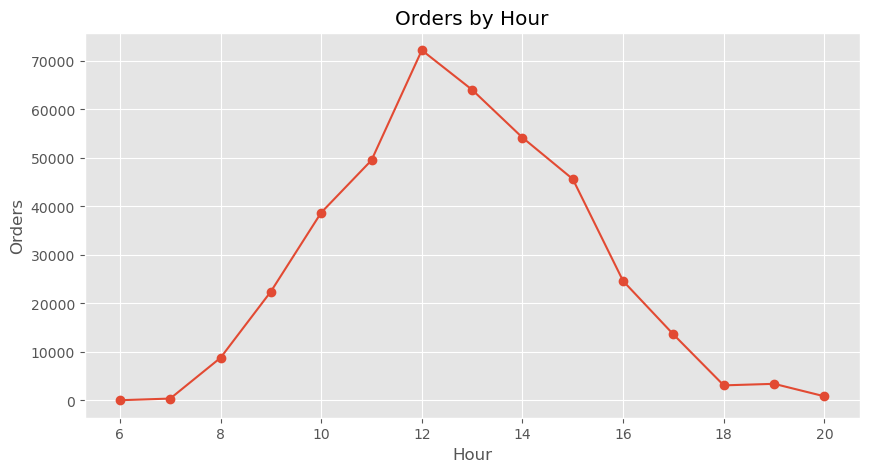

In [97]:
orders_hour = df.groupby("Hour")["InvoiceNo"].count()

plt.figure(figsize=(10,5))
orders_hour.plot(marker="o")
plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.show()

#### Orders by Weekday

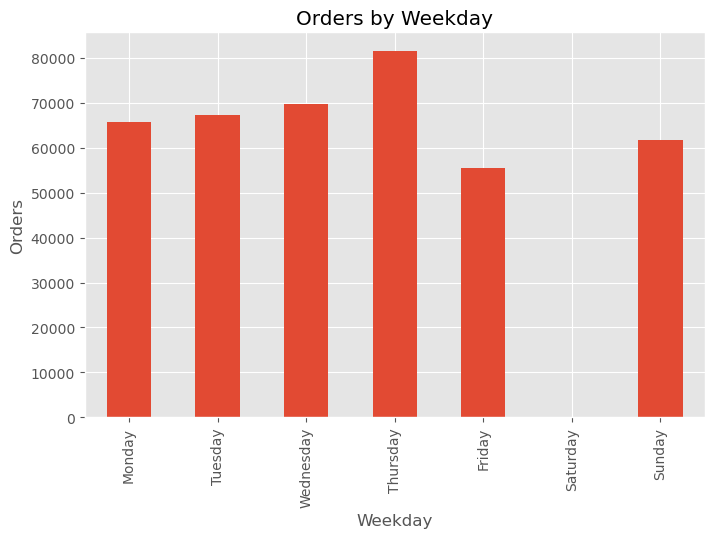

In [98]:
weekday_orders = df.groupby("Weekday")["InvoiceNo"].count().reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(8,5))
weekday_orders.plot(kind="bar")
plt.title("Orders by Weekday")
plt.ylabel("Orders")
plt.show()

#### Returns by Product

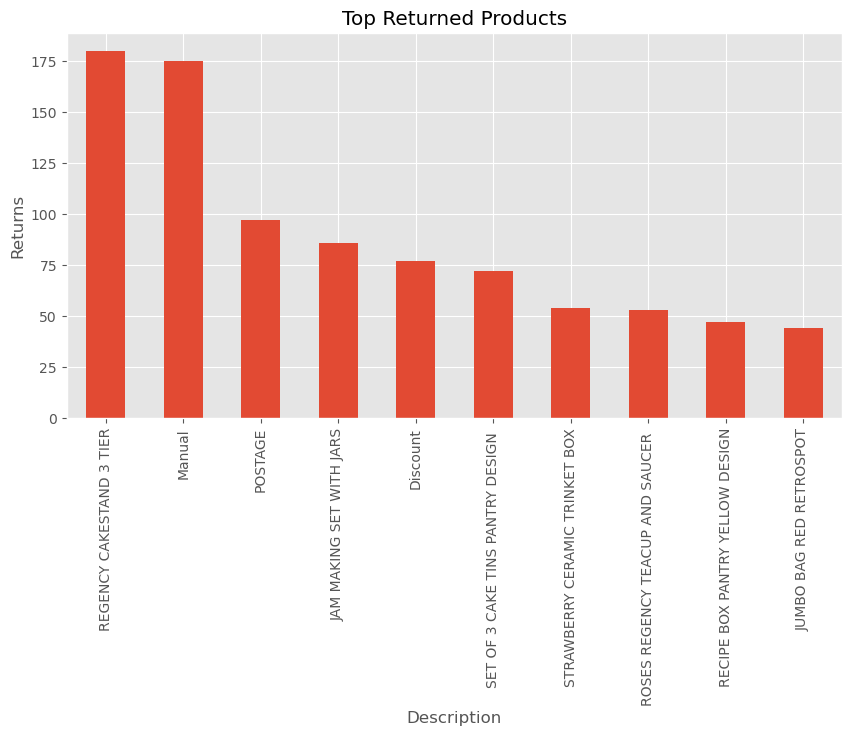

In [99]:
returns = df[df["Quantity"]<0]

top_returns = returns["Description"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_returns.plot(kind="bar")
plt.title("Top Returned Products")
plt.ylabel("Returns")
plt.show()

## Business Insights

1. The United Kingdom generated the highest revenue and dominated overall sales.

2. Revenue reached its peak during November, indicating strong seasonal demand before Christmas.

3. A small number of products accounted for a significant portion of total sales.

4. Most customers made only one or two purchases, while a few high-value customers contributed a large share of the revenue.

5. Several products showed a high return rate, suggesting possible issues related to quality, customer expectations, or product descriptions.

6. Sales activity was highest during business hours, indicating that customers preferred shopping during the daytime.